In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fanalysis.ca import CA
from matplotlib.ticker import PercentFormatter

data = pd.read_csv('data.csv')

### Diagrammes en barre décrivant la proportion de chaque item en fonction de l'étape du raisonnement clinique.  

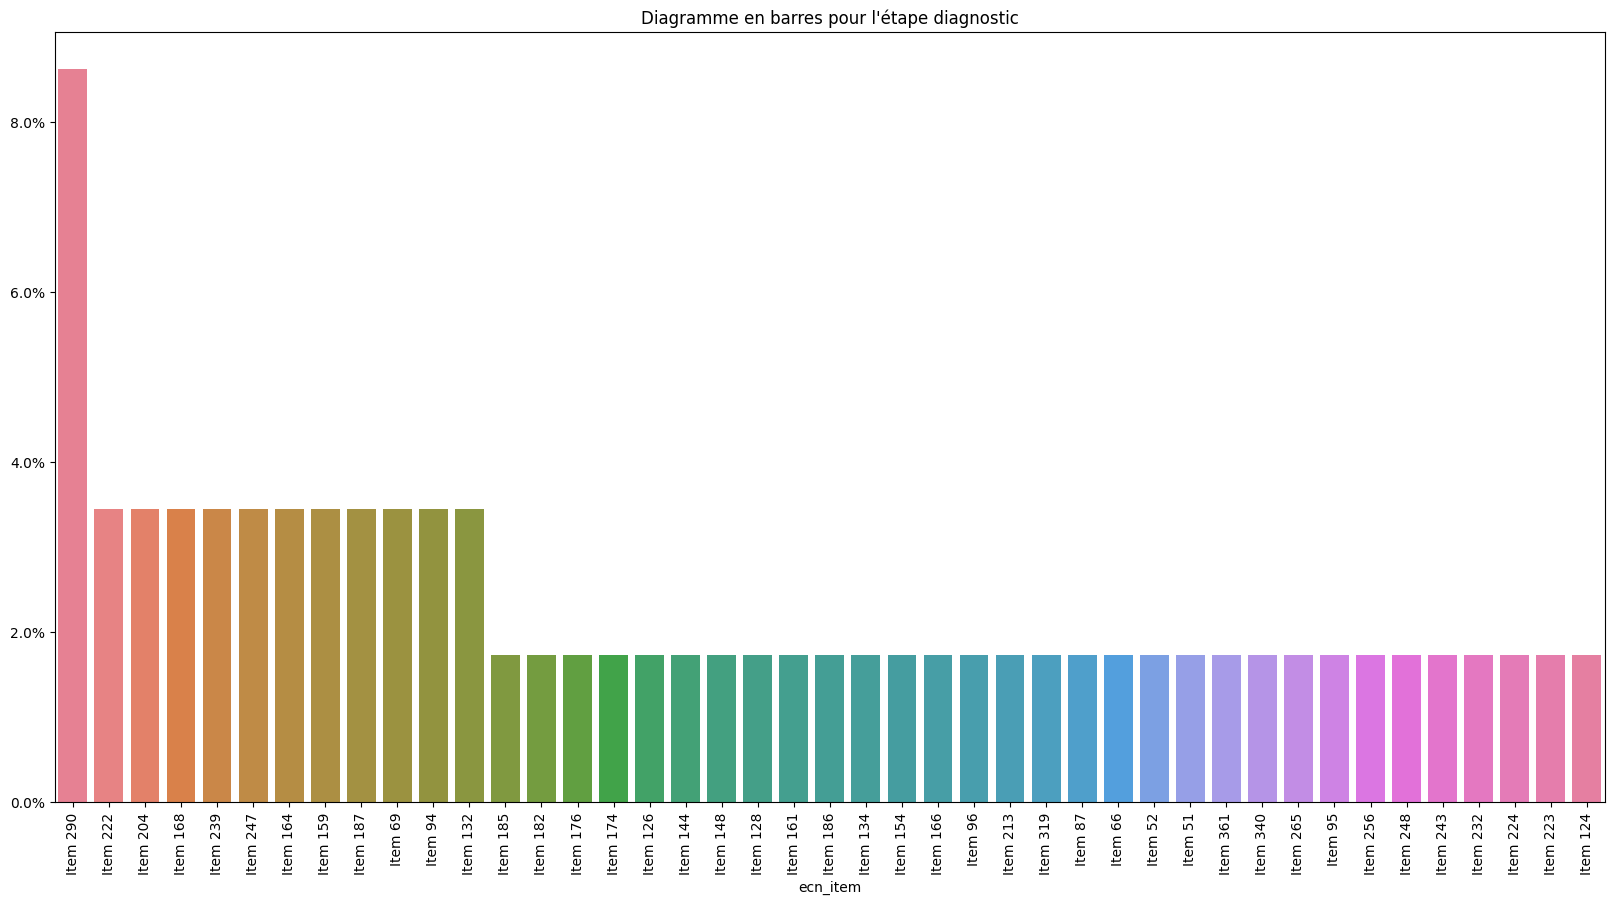

Valeurs absolues : 



ecn_item,Item 290,Item 222,Item 204,Item 168,Item 239,Item 247,Item 164,Item 159,Item 187,Item 69,...,Item 340,Item 265,Item 95,Item 256,Item 248,Item 243,Item 232,Item 224,Item 223,Item 124
diagnostic,5,2,2,2,2,2,2,2,2,2,...,1,1,1,1,1,1,1,1,1,1


Proportions : 



ecn_item,Item 290,Item 222,Item 204,Item 168,Item 239,Item 247,Item 164,Item 159,Item 187,Item 69,...,Item 340,Item 265,Item 95,Item 256,Item 248,Item 243,Item 232,Item 224,Item 223,Item 124
diagnostic,0.086207,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,...,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241


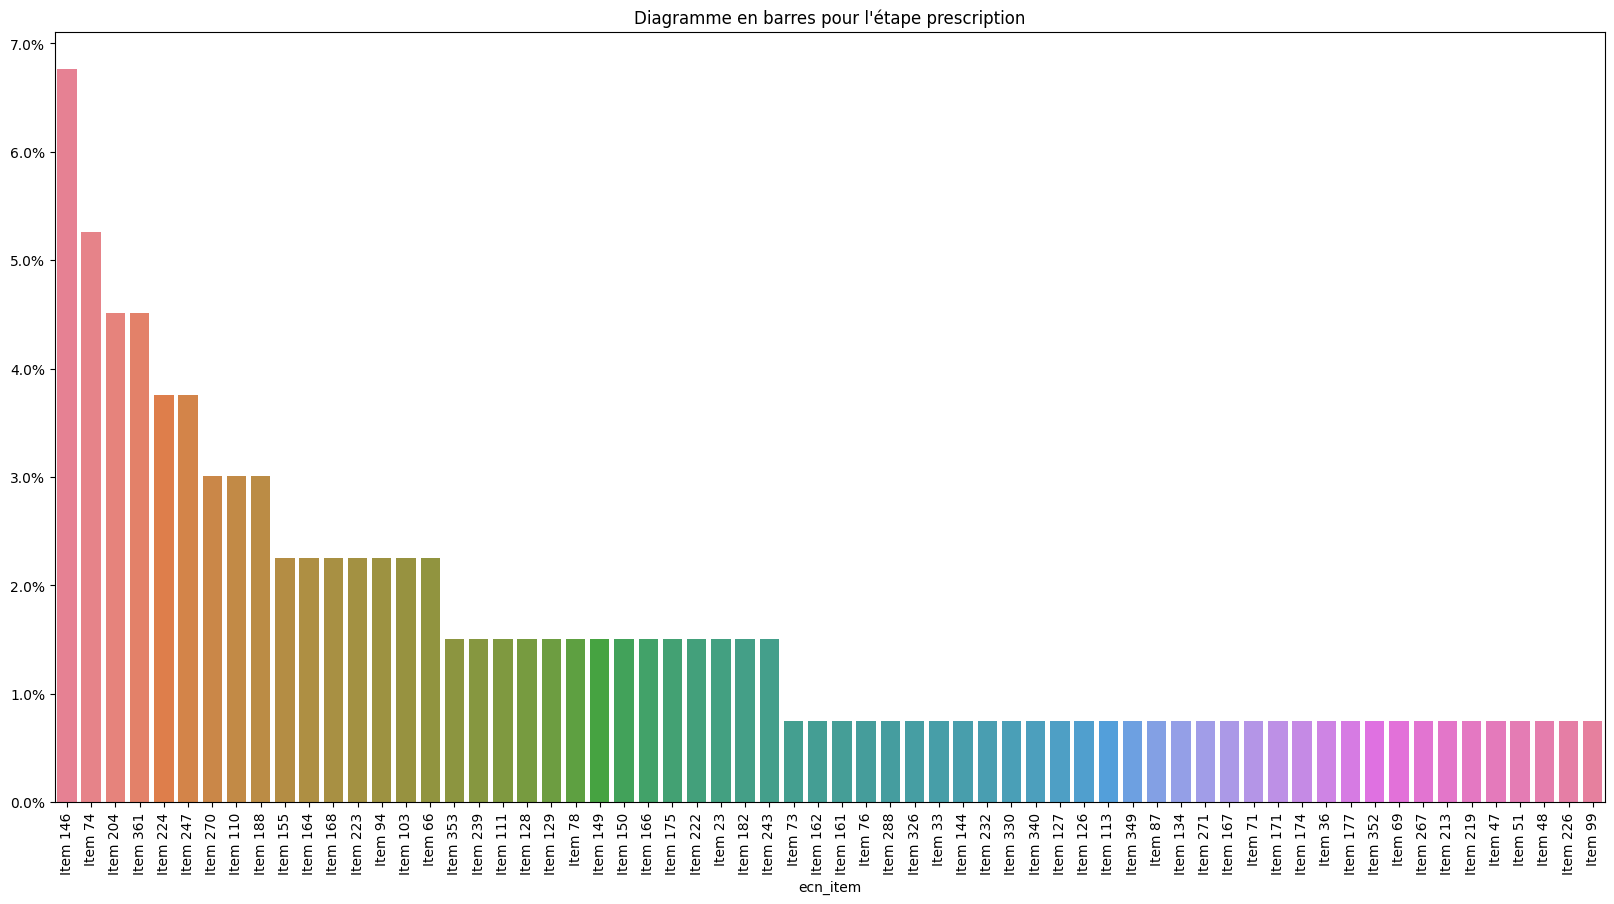

Valeurs absolues : 



ecn_item,Item 146,Item 74,Item 204,Item 361,Item 224,Item 247,Item 270,Item 110,Item 188,Item 155,...,Item 352,Item 69,Item 267,Item 213,Item 219,Item 47,Item 51,Item 48,Item 226,Item 99
prescription,9,7,6,6,5,5,4,4,4,3,...,1,1,1,1,1,1,1,1,1,1


Proportions : 



ecn_item,Item 146,Item 74,Item 204,Item 361,Item 224,Item 247,Item 270,Item 110,Item 188,Item 155,...,Item 352,Item 69,Item 267,Item 213,Item 219,Item 47,Item 51,Item 48,Item 226,Item 99
prescription,0.067669,0.052632,0.045113,0.045113,0.037594,0.037594,0.030075,0.030075,0.030075,0.022556,...,0.007519,0.007519,0.007519,0.007519,0.007519,0.007519,0.007519,0.007519,0.007519,0.007519


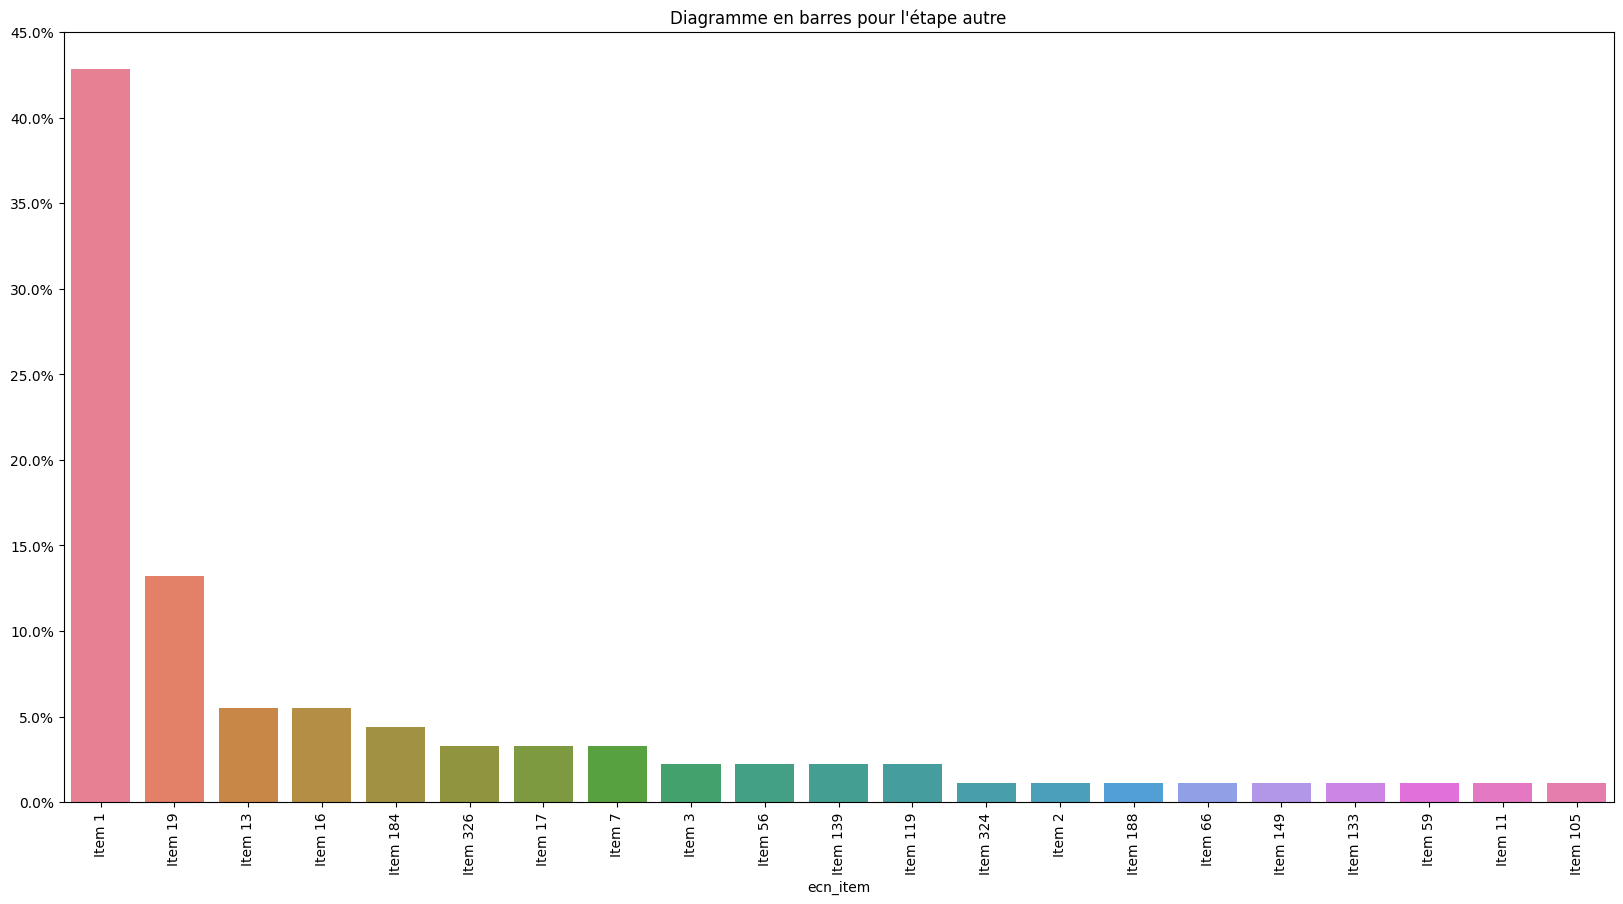

Valeurs absolues : 



ecn_item,Item 1,Item 19,Item 13,Item 16,Item 184,Item 326,Item 17,Item 7,Item 3,Item 56,...,Item 119,Item 324,Item 2,Item 188,Item 66,Item 149,Item 133,Item 59,Item 11,Item 105
autre,39,12,5,5,4,3,3,3,2,2,...,2,1,1,1,1,1,1,1,1,1


Proportions : 



ecn_item,Item 1,Item 19,Item 13,Item 16,Item 184,Item 326,Item 17,Item 7,Item 3,Item 56,...,Item 119,Item 324,Item 2,Item 188,Item 66,Item 149,Item 133,Item 59,Item 11,Item 105
autre,0.428571,0.131868,0.054945,0.054945,0.043956,0.032967,0.032967,0.032967,0.021978,0.021978,...,0.021978,0.010989,0.010989,0.010989,0.010989,0.010989,0.010989,0.010989,0.010989,0.010989


In [2]:
data_gpByItem = data.groupby(['ecn_item']).agg(
    diagnostic = ('step_diag', 'sum'),
    prescription = ('step_PEC_TTT', 'sum'), 
    autre = ('step_autre', 'sum')
)

data_gpByItem = data_gpByItem.transpose()

for i in range(0,data_gpByItem.shape[0]):
    row = data_gpByItem.iloc[[i]]
    row = row.dropna(axis=1, how='all')
    row = row.loc[:, row.iloc[0] != 0]
    row = row[row.columns[row.iloc[0].argsort()[::-1]]]

    rowProp = row.copy()
    rowProp[row.columns] = row[row.columns].div(row[row.columns].sum(axis=1), axis=0)

    plt.figure(figsize=(20, 10))
    sns.barplot(rowProp)
    plt.xticks(rotation=90)
    plt.title(f"Diagramme en barres pour l'étape {data_gpByItem.index[i]}")
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.show()  
    print("Valeurs absolues : \n")
    display(row)
    print("Proportions : \n")
    display(rowProp)
